
This code aligns the column headers to match those of the signature matrix. It also scales the tissue proportions to 100% for the different tools that their output is sum to 1 (CIBERSORTx, MuSiC and BayesPrism).

BayesPrism contains pancreatic.pp.cell which is absent from the rest (not even as without the spaces). This cell type is included in the initial reference but was probably excluded because it contains only 2 cells in the whole reference.

In [1]:
import os
import glob
import pandas as pd

# Define the root directory
root_dir = 'COO-Decon-Degradation'


# Helper function to normalize row sums to 100
def normalize_to_100(df):
    sample_col = df.columns[0]
    columns_to_normalize = [col for col in df.columns if col != sample_col and pd.api.types.is_numeric_dtype(df[col])]
    df[columns_to_normalize] = df[columns_to_normalize].div(df[columns_to_normalize].sum(axis=1), axis=0) * 100
    return df

# Get all TSP-*Random_v2 subdirectories
subdirs = [d for d in glob.glob(os.path.join(root_dir, 'TSP-BDa_Outer_300_1500_10_Random_v2C_top_*_percent_removed')) if os.path.isdir(d)]

# Loop through each subdirectory
for subdir in subdirs:
    for file in os.listdir(subdir):
        if file.endswith('.txt') and not file.endswith('modified.txt'):
            file_path = os.path.join(subdir, file)

            try:
                df = pd.read_csv(file_path, sep="\t", index_col=0)

                if (
                    file.endswith('BayesPrism_renamed.txt') or
                    file.endswith('MuSiC.txt') or 
                    file.startswith('CIBERSORTx_Results') or
                    file.endswith('ReDeconv_results.txt')
                ):
                    if file.startswith('CIBERSORTx_Results'):
                        columns_to_exclude = ['P-value', 'Correlation', 'RMSE']
                        df = df.drop(columns=columns_to_exclude, errors='ignore')

                    df = normalize_to_100(df)
                if file.startswith('QP') or file.startswith('NNLS'):
                    columns_to_exclude = ['RMSE-Composition', 'r-Composition', 'RMSE-PredictedCounts', 'r-PredictedCounts']
                    df = df.drop(columns=columns_to_exclude, errors='ignore')

                # Round and save
                df = df.round(5)
                output_file_path = file_path.replace('.txt', '_modified.txt')
                df.to_csv(output_file_path, sep='\t')
                print(f"Processed and saved: {output_file_path}")

            except Exception as e:
                print(f"Error processing {file_path}: {e}")


Processed and saved: COO-Decon-Degradation/TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/CIBERSORTx_Results_Merged_modified.txt
Processed and saved: COO-Decon-Degradation/TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/NNLS_Random_v2C_top_10_percent_removed_modified.txt
Processed and saved: COO-Decon-Degradation/TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/TSP-HBA_Inner_100each_seed42_filtered_Random_v2C_top_10_percent_removed_prop_weights_MuSiC_modified.txt
Processed and saved: COO-Decon-Degradation/TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/TSP-BDa_Inner_100each_seed42_filtered_Random_v2C_top_10_percent_removed_BayesPrism_renamed_modified.txt
Processed and saved: COO-Decon-Degradation/TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/nuSVR_Counts_TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed_modified.txt
Processed and saved: COO-Decon-Degradation/TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_remov

The proportion files are the same as those from the COO-Decon-Pseudobulks directory.

Since different matrices are used for each tool (best matrix per tool), the spillover should be calculated using the specific proportions file used in that specific tool.

In [2]:
import pandas as pd
import numpy as np
import os
from glob import glob

# === Load and normalize ground truth ===
prop_df = pd.read_csv("COO-Decon-Pseudobulks/TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt", sep='\t', index_col=0)

# Remove TotalCells if present
if "TotalCells" in prop_df.columns:
    prop_df.drop(columns=["TotalCells"], inplace=True)

# Define reference tissue list (from columns in ground truth)
reference_tissues = prop_df.columns.tolist()

# Normalize to 100% per row and round
prop_df_tissues = prop_df[reference_tissues].copy()
prop_df_tissues = prop_df_tissues.div(prop_df_tissues.sum(axis=1), axis=0).multiply(100).round(5)
prop_df.update(prop_df_tissues)

# === Glob all *_modified.txt files, then filter ===
all_files = sorted(glob("TSP-BDa_Outer_300_1500_10_Random_v2C_top_*_percent_removed/*_modified.txt"))

# Keep only BayesPrism, NNLS, or QP files
modified_files = [f for f in all_files if any(x in os.path.basename(f) for x in ["BayesPrism", "NNLS", "QP"])]

print(f"Found {len(modified_files)} prediction files.\n")

# === Process each file ===
for file_path in modified_files:
    try:
        print(f"Processing: {file_path}")

        # Read predictions (first column = index)
        decon_df = pd.read_csv(file_path, sep='\t', index_col=0)

        # Strip noise suffix (_ptX.XX) from prediction indices
        decon_df.index = decon_df.index.str.replace(r'_pt\d+\.\d+$', '', regex=True)

        # Ensure all reference columns exist
        for col in reference_tissues:
            if col not in decon_df.columns:
                decon_df[col] = 0.0
        decon_df = decon_df[reference_tissues]

        # Subset to matching samples
        common_samples = prop_df.index.intersection(decon_df.index)
        print(f"  Matched {len(common_samples)} samples")

        # Subset and align both
        true_vals_df = prop_df.loc[common_samples, reference_tissues]
        pred_vals_df = decon_df.loc[common_samples, reference_tissues]

        # Normalize predicted values to 100%
        pred_vals_df = pred_vals_df.div(pred_vals_df.sum(axis=1), axis=0).multiply(100).round(5)

        # Compute spillover = absolute error
        spillover_df = (pred_vals_df - true_vals_df).abs()

        # Save spillover result
        out_path = file_path.replace('_modified.txt', '_Spillover.txt')
        spillover_df.to_csv(out_path, sep='\t')
        print(f"  Saved spillover: {out_path}\n")

    except Exception as e:
        print(f"Error processing {file_path}: {e}\n")

Found 15 prediction files.

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/NNLS_Random_v2C_All-Counts_modified.txt
  Matched 825 samples
  Saved spillover: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/NNLS_Random_v2C_All-Counts_Spillover.txt

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/QP_Random_v2C_All-Counts_modified.txt
  Matched 825 samples
  Saved spillover: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/QP_Random_v2C_All-Counts_Spillover.txt

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/TSP-BDa_Inner_100each_seed42_filtered_Random_v2C_All-Counts_BayesPrism_renamed_modified.txt
  Matched 825 samples
  Saved spillover: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/TSP-BDa_Inner_100each_seed42_filtered_Random_v2C_All-Counts_BayesPrism_renamed_Spillover.txt

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/NNLS_Random_v2C_top_10_percent_removed_mo

In [3]:
import pandas as pd
import numpy as np
import os
from glob import glob

# === Load and normalize ground truth ===
prop_df = pd.read_csv("COO-Decon-Pseudobulks/TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt", sep='\t', index_col=0)
# Remove TotalCells if present
if "TotalCells" in prop_df.columns:
    prop_df.drop(columns=["TotalCells"], inplace=True)

# Define reference tissue list (from columns in ground truth)
reference_tissues = prop_df.columns.tolist()

# Normalize to 100% per row and round
prop_df_tissues = prop_df[reference_tissues].copy()
prop_df_tissues = prop_df_tissues.div(prop_df_tissues.sum(axis=1), axis=0).multiply(100).round(5)
prop_df.update(prop_df_tissues)

# === Glob all *_modified.txt files, then filter ===
all_files = sorted(glob("TSP-BDa_Outer_300_1500_10_Random_v2C_top_*_percent_removed/*_modified.txt"))

# Keep only BayesPrism, NNLS, or QP files
modified_files = [f for f in all_files if any(x in os.path.basename(f) for x in ["CIBERSORTx", "nuSVR"])]

print(f"Found {len(modified_files)} prediction files.\n")

# === Process each file ===
for file_path in modified_files:
    try:
        print(f"Processing: {file_path}")

        # Read predictions (first column = index)
        decon_df = pd.read_csv(file_path, sep='\t', index_col=0)

        # Strip noise suffix (_ptX.XX) from prediction indices
        decon_df.index = decon_df.index.str.replace(r'_pt\d+\.\d+$', '', regex=True)

        # Ensure all reference columns exist
        for col in reference_tissues:
            if col not in decon_df.columns:
                decon_df[col] = 0.0
        decon_df = decon_df[reference_tissues]

        # Subset to matching samples
        common_samples = prop_df.index.intersection(decon_df.index)
        print(f"  Matched {len(common_samples)} samples")

        # Subset and align both
        true_vals_df = prop_df.loc[common_samples, reference_tissues]
        pred_vals_df = decon_df.loc[common_samples, reference_tissues]

        # Normalize predicted values to 100%
        pred_vals_df = pred_vals_df.div(pred_vals_df.sum(axis=1), axis=0).multiply(100).round(5)

        # Compute spillover = absolute error
        spillover_df = (pred_vals_df - true_vals_df).abs()

        # Save spillover result
        out_path = file_path.replace('_modified.txt', '_Spillover.txt')
        spillover_df.to_csv(out_path, sep='\t')
        print(f"  Saved spillover: {out_path}\n")

    except Exception as e:
        print(f"Error processing {file_path}: {e}\n")

Found 10 prediction files.

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/CIBERSORTx_Results_Merged_modified.txt
  Matched 825 samples
  Saved spillover: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/CIBERSORTx_Results_Merged_Spillover.txt

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/nuSVR_Counts_TSP-BDa_Outer_300_1500_10_v2C_modified.txt
  Matched 818 samples
  Saved spillover: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/nuSVR_Counts_TSP-BDa_Outer_300_1500_10_v2C_Spillover.txt

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/CIBERSORTx_Results_Merged_modified.txt
  Matched 825 samples
  Saved spillover: TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/CIBERSORTx_Results_Merged_Spillover.txt

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/nuSVR_Counts_TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed_modified.txt
  Matched 825 samples
  S

In [4]:
import pandas as pd
import numpy as np
import os
from glob import glob

# === Load and normalize ground truth ===
prop_df = pd.read_csv("COO-Decon-Pseudobulks/TSP-HBA_Inner_Random_v2C_New_All-Proportions.txt", sep='\t', index_col=0)

# Remove TotalCells if present
if "TotalCells" in prop_df.columns:
    prop_df.drop(columns=["TotalCells"], inplace=True)

# Define reference tissue list (from columns in ground truth)
reference_tissues = prop_df.columns.tolist()

# Normalize to 100% per row and round
prop_df_tissues = prop_df[reference_tissues].copy()
prop_df_tissues = prop_df_tissues.div(prop_df_tissues.sum(axis=1), axis=0).multiply(100).round(5)
prop_df.update(prop_df_tissues)

# === Glob all *_modified.txt files, then filter ===
all_files = sorted(glob("TSP-BDa_Outer_300_1500_10_Random_v2C_top_*_percent_removed/*_modified.txt"))

# Keep only MuSiC or ReDeconv files
modified_files = [f for f in all_files if any(x in os.path.basename(f) for x in ["MuSiC", "ReDeconv"])]

print(f"Found {len(modified_files)} prediction files.\n")

# === Process each file ===
for file_path in modified_files:
    try:
        print(f"Processing: {file_path}")

        # Read predictions (first column = index)
        decon_df = pd.read_csv(file_path, sep='\t', index_col=0)

        # Strip noise suffix (_ptX.XX) from prediction indices
        decon_df.index = decon_df.index.str.replace(r'_pt\d+\.\d+$', '', regex=True)

        # Ensure all reference columns exist
        for col in reference_tissues:
            if col not in decon_df.columns:
                decon_df[col] = 0.0
        decon_df = decon_df[reference_tissues]

        # Subset to matching samples
        common_samples = prop_df.index.intersection(decon_df.index)
        print(f"  Matched {len(common_samples)} samples")

        # Subset and align both
        true_vals_df = prop_df.loc[common_samples, reference_tissues]
        pred_vals_df = decon_df.loc[common_samples, reference_tissues]

        # Normalize predicted values to 100%
        pred_vals_df = pred_vals_df.div(pred_vals_df.sum(axis=1), axis=0).multiply(100).round(5)

        # Compute spillover = absolute error
        spillover_df = (pred_vals_df - true_vals_df).abs()

        # Save spillover result
        out_path = file_path.replace('_modified.txt', '_Spillover.txt')
        spillover_df.to_csv(out_path, sep='\t')
        print(f"  Saved spillover: {out_path}\n")

    except Exception as e:
        print(f"Error processing {file_path}: {e}\n")

Found 10 prediction files.

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/TSP-HBA_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results_modified.txt
  Matched 825 samples
  Saved spillover: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/TSP-HBA_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results_Spillover.txt

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/TSP-HBA_Inner_100each_seed42_filtered_Random_v1_prop_weights_MuSiC_modified.txt
  Matched 825 samples
  Saved spillover: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed/TSP-HBA_Inner_100each_seed42_filtered_Random_v1_prop_weights_MuSiC_Spillover.txt

Processing: TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/TSP-HBA_Inner_100each_seed42_Random_v2C_top_10_percent_removed_Top1500_ReDeconv_results_modified.txt
  Matched 825 samples
  Saved spillover: TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed/TSP-HBA_Inner_100each_seed42_Random_v2C_

In [5]:
# This script collects average spillover (MAE) values from all *_Spillover.txt files
# in the Random TOOv2 deconvolution results directories.
# It merges them into a dataframe with columns:
# Sample, Method, Matrix, RemovedGenes, and Average_MAE.

import os
import re
import pandas as pd
from glob import glob
# === CONFIGURATION ===
root_dir = 'COO-Decon-Degradation'
method_map = ['CIBERSORTx', 'MuSiC', 'QP', 'NNLS', 'BayesPrism', 'nuSVR', 'ReDeconv']

# === GATHER RESULT DIRECTORIES ===
random_dirs = sorted(glob(os.path.join(root_dir, 'TSP-BDa_Outer_300_1500_10_Random_v2C_top_*_percent_removed')))
spillover_data = []

# === PROCESS EACH DIRECTORY ===
for dir_path in random_dirs:
    # Find spillover files by substring match (more robust than glob)
    spillover_files = [f for f in os.listdir(dir_path) if "Spillover" in f]
    spillover_files = [os.path.join(dir_path, f) for f in spillover_files]

    print(f"Directory: {dir_path}, found {len(spillover_files)} spillover files")

    # Extract numeric part of "top_X_percent_removed"
    dir_name = os.path.basename(dir_path)
    match = re.search(r'top_(\d+)_percent_removed', dir_name)
    removed_label = int(match.group(1)) if match else None

    for file_path in spillover_files:
        try:
            # Load spillover values
            df = pd.read_csv(file_path, sep='\t', index_col=0)

            print(f"  Processing {os.path.basename(file_path)} shape={df.shape}")

            # Compute average and total spillover per sample
            avg_mae = df.mean(axis=1)
            total_mae = df.sum(axis=1)

            # Extract method name from file name
            filename = os.path.basename(file_path)
            raw_method = filename.replace('_Spillover.txt', '').replace('_Spillover.tsv', '')
            method = next((m for m in method_map if m in raw_method), raw_method)

            # Build clean dataframe
            clean_df = pd.DataFrame({
                'Sample': df.index,
                'Method': method,
                'RemovedGenes': removed_label,
                'Average_AE': avg_mae.values,
                'Total_AE': total_mae.values
            })

            spillover_data.append(clean_df)

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# === MERGE ALL RESULTS ===
if spillover_data:
    merged_df = pd.concat(spillover_data, ignore_index=True)
    output_path = 'merged_Results_Spillover_Random_COO_v4_DegradationGenes.txt'
    merged_df.to_csv(output_path, sep='\t', index=False)
    print(f"Saved merged spillover results: {output_path}")
else:
    print("No spillover data collected! Check file patterns.")

Directory: COO-Decon-Degradation/TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed, found 7 spillover files
  Processing TSP-HBA_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results_Spillover.txt shape=(825, 69)
  Processing nuSVR_Counts_TSP-BDa_Outer_300_1500_10_v2C_Spillover.txt shape=(818, 80)
  Processing QP_Random_v2C_All-Counts_Spillover.txt shape=(825, 80)
  Processing TSP-HBA_Inner_100each_seed42_filtered_Random_v1_prop_weights_MuSiC_Spillover.txt shape=(825, 69)
  Processing NNLS_Random_v2C_All-Counts_Spillover.txt shape=(825, 80)
  Processing CIBERSORTx_Results_Merged_Spillover.txt shape=(825, 80)
  Processing TSP-BDa_Inner_100each_seed42_filtered_Random_v2C_All-Counts_BayesPrism_renamed_Spillover.txt shape=(825, 80)
Directory: COO-Decon-Degradation/TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed, found 7 spillover files
  Processing nuSVR_Counts_TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed_Spillover.txt shape=(825, 80)
  Processing NNLS_

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# === LOAD DATA ===
file_path = 'merged_Results_Spillover_Random_COO_v4_DegradationGenes.txt'
df = pd.read_csv(file_path, sep='\t')

# === ENSURE NUMERIC NOISE LEVEL FOR ORDERING ===
df['RemovedGenesNumeric'] = pd.to_numeric(df['RemovedGenes'], errors='coerce')

# === PIVOT TO METHOD × NOISE LEVEL ===
pivot_df = df.pivot_table(
    index='Method',
    columns='RemovedGenesNumeric',
    values='Total_AE',     # Total AE values
    aggfunc='mean'
).sort_index(axis=1)

# === REORDER ROWS ===
method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
pivot_df = pivot_df.reindex(method_order)

# === PLOT HEATMAP ===
fig, ax = plt.subplots(figsize=(6, 4), dpi=600, constrained_layout=True)
ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',             
#    annot=True,
#    fmt=".1f",
#    annot_kws={"size": 10},
    cbar_kws={'label': 'Total Absolute Error', 'shrink': 0.9},
    linewidths=0,
    linecolor='white'
)

# Force ticks to show
ax.tick_params(
    axis='x', which='both', bottom=True, top=False, labelbottom=True,
    length=4, width=0.6
)
ax.tick_params(
    axis='y', which='both', left=True, right=False, labelleft=True,
    length=4, width=0.6
)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Total Absolute Error", fontsize=13, rotation = 270, labelpad=20)   
cbar.ax.tick_params(labelsize=11, width=0.8, length=4)    
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))

# === Axes styling ===
plt.ylabel('Deconvolution Tool', fontsize=14, labelpad=10)
plt.xlabel('Genes Removed (%)', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# === SAVE FIGURE ===
fig.savefig("Total_AE_Heatmap_Best-Matrix_Degradation_Clean.svg")
plt.close(fig)


In [9]:
import os
import re
import pandas as pd
import numpy as np
from glob import glob
from scipy.stats import pearsonr

# === CONFIGURATION ===
root_dir = 'COO-Decon-Degradation'
method_map = ['BayesPrism', 'nuSVR', 'ReDeconv', 'CIBERSORTx', 'MuSiC', 'NNLS', 'QP']

# === Define proportion file by method ===
prop_files = {
    'MuSiC': "COO-Decon-Pseudobulks/TSP-HBA_Inner_Random_v2C_New_All-Proportions.txt",
    'ReDeconv': "COO-Decon-Pseudobulks/TSP-HBA_Inner_Random_v2C_New_All-Proportions.txt",
    'CIBERSORTx': "COO-Decon-Pseudobulks/TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt",
    'nuSVR': "COO-Decon-Pseudobulks/TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt",
    'BayesPrism': "COO-Decon-Pseudobulks/TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt",
    'NNLS': "COO-Decon-Pseudobulks/TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt",
    'QP': "COO-Decon-Pseudobulks/TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt"
}

# === Locate input directories ===
input_dirs = sorted(glob(os.path.join(root_dir, 'TSP-BDa_Outer_300_1500_10_Random_v2C_top_*_percent_removed')))
all_results = []

print(f"Found {len(input_dirs)} top_removed directories")

# === MAIN LOOP ===
for input_dir in input_dirs:
    dir_name = os.path.basename(input_dir)
    match = re.search(r'top_(\d+)_percent_removed', dir_name)
    removed_label = int(match.group(1)) if match else None

    print(f"\n=== Processing directory: {dir_name} (RemovedGenes = {removed_label}) ===")
    decon_files = sorted(glob(os.path.join(input_dir, '*_modified.txt')))

    if not decon_files:
        print(" No deconvolution files found.")
        continue

    for file_path in decon_files:
        filename = os.path.basename(file_path)
        method = next((m for m in method_map if m in filename), None)
        if not method:
            print(f" Could not identify method in {filename}")
            continue

        # === Load correct proportion file ===
        prop_file = prop_files[method]
        prop_df = pd.read_csv(prop_file, sep='\t', index_col=0)

        # Drop TotalCells if present
        if "TotalCells" in prop_df.columns:
            prop_df = prop_df.drop(columns=["TotalCells"])

        # Normalize to percentage
        prop_df = prop_df.div(prop_df.sum(axis=1), axis=0).multiply(100).round(5)

        # Load deconvolution results
        try:
            decon_df = pd.read_csv(file_path, sep='\t', index_col=0)
        except Exception as e:
            print(f" Error reading {file_path}: {e}")
            continue

        # Align samples and columns
        common_samples = prop_df.index.intersection(decon_df.index)
        if common_samples.empty:
            print(f" No common samples for {method}")
            continue

        common_cols = prop_df.columns.intersection(decon_df.columns)
        if common_cols.empty:
            print(f" No matching columns for {method}")
            continue

        # Extract matching data
        true_vals_df = prop_df.loc[common_samples, common_cols]
        pred_vals_df = decon_df.loc[common_samples, common_cols]

        # Flatten and filter zero-zero pairs
        true_vals = true_vals_df.values.flatten()
        pred_vals = pred_vals_df.values.flatten()
        mask = ~((true_vals == 0) & (pred_vals == 0))
        true_vals, pred_vals = true_vals[mask], pred_vals[mask]

        if len(true_vals) < 2:
            print(f" Not enough data for {method}")
            continue

        # Pearson correlation
        r, p = pearsonr(true_vals, pred_vals)
        all_results.append([dir_name, method, removed_label, r, r**2, p])
        print(f"  {method}: r = {r:.4f}, R² = {r**2:.4f}, p = {p:.2e}")

# === SAVE SUMMARY ===
if all_results:
    results_df = pd.DataFrame(
        all_results,
        columns=["InputDir", "Method", "RemovedGenes", "Pearson_r", "R_squared", "p_value"]
    )
    results_csv = os.path.join(root_dir, "All_Pearson_Summary.csv")
    results_df.to_csv(results_csv, sep='\t', index=False)
    print(f"\n Saved summary table: {results_csv}")
else:
    print("\n⚠️ No results computed.")


Found 5 top_removed directories

=== Processing directory: TSP-BDa_Outer_300_1500_10_Random_v2C_top_0_percent_removed (RemovedGenes = 0) ===
  CIBERSORTx: r = 0.7764, R² = 0.6029, p = 0.00e+00
  NNLS: r = 0.4713, R² = 0.2222, p = 0.00e+00
  QP: r = 0.3798, R² = 0.1442, p = 0.00e+00
  BayesPrism: r = 0.8150, R² = 0.6643, p = 0.00e+00
  ReDeconv: r = 0.7864, R² = 0.6184, p = 0.00e+00
  MuSiC: r = 0.7425, R² = 0.5513, p = 0.00e+00
  nuSVR: r = 0.5590, R² = 0.3125, p = 0.00e+00

=== Processing directory: TSP-BDa_Outer_300_1500_10_Random_v2C_top_10_percent_removed (RemovedGenes = 10) ===
  CIBERSORTx: r = 0.7614, R² = 0.5797, p = 0.00e+00
  NNLS: r = 0.4327, R² = 0.1872, p = 0.00e+00
  QP: r = 0.3933, R² = 0.1547, p = 0.00e+00
  BayesPrism: r = 0.8115, R² = 0.6586, p = 0.00e+00
  ReDeconv: r = 0.7846, R² = 0.6156, p = 0.00e+00
  MuSiC: r = 0.7412, R² = 0.5494, p = 0.00e+00
  nuSVR: r = 0.5506, R² = 0.3031, p = 0.00e+00

=== Processing directory: TSP-BDa_Outer_300_1500_10_Random_v2C_top_20_p

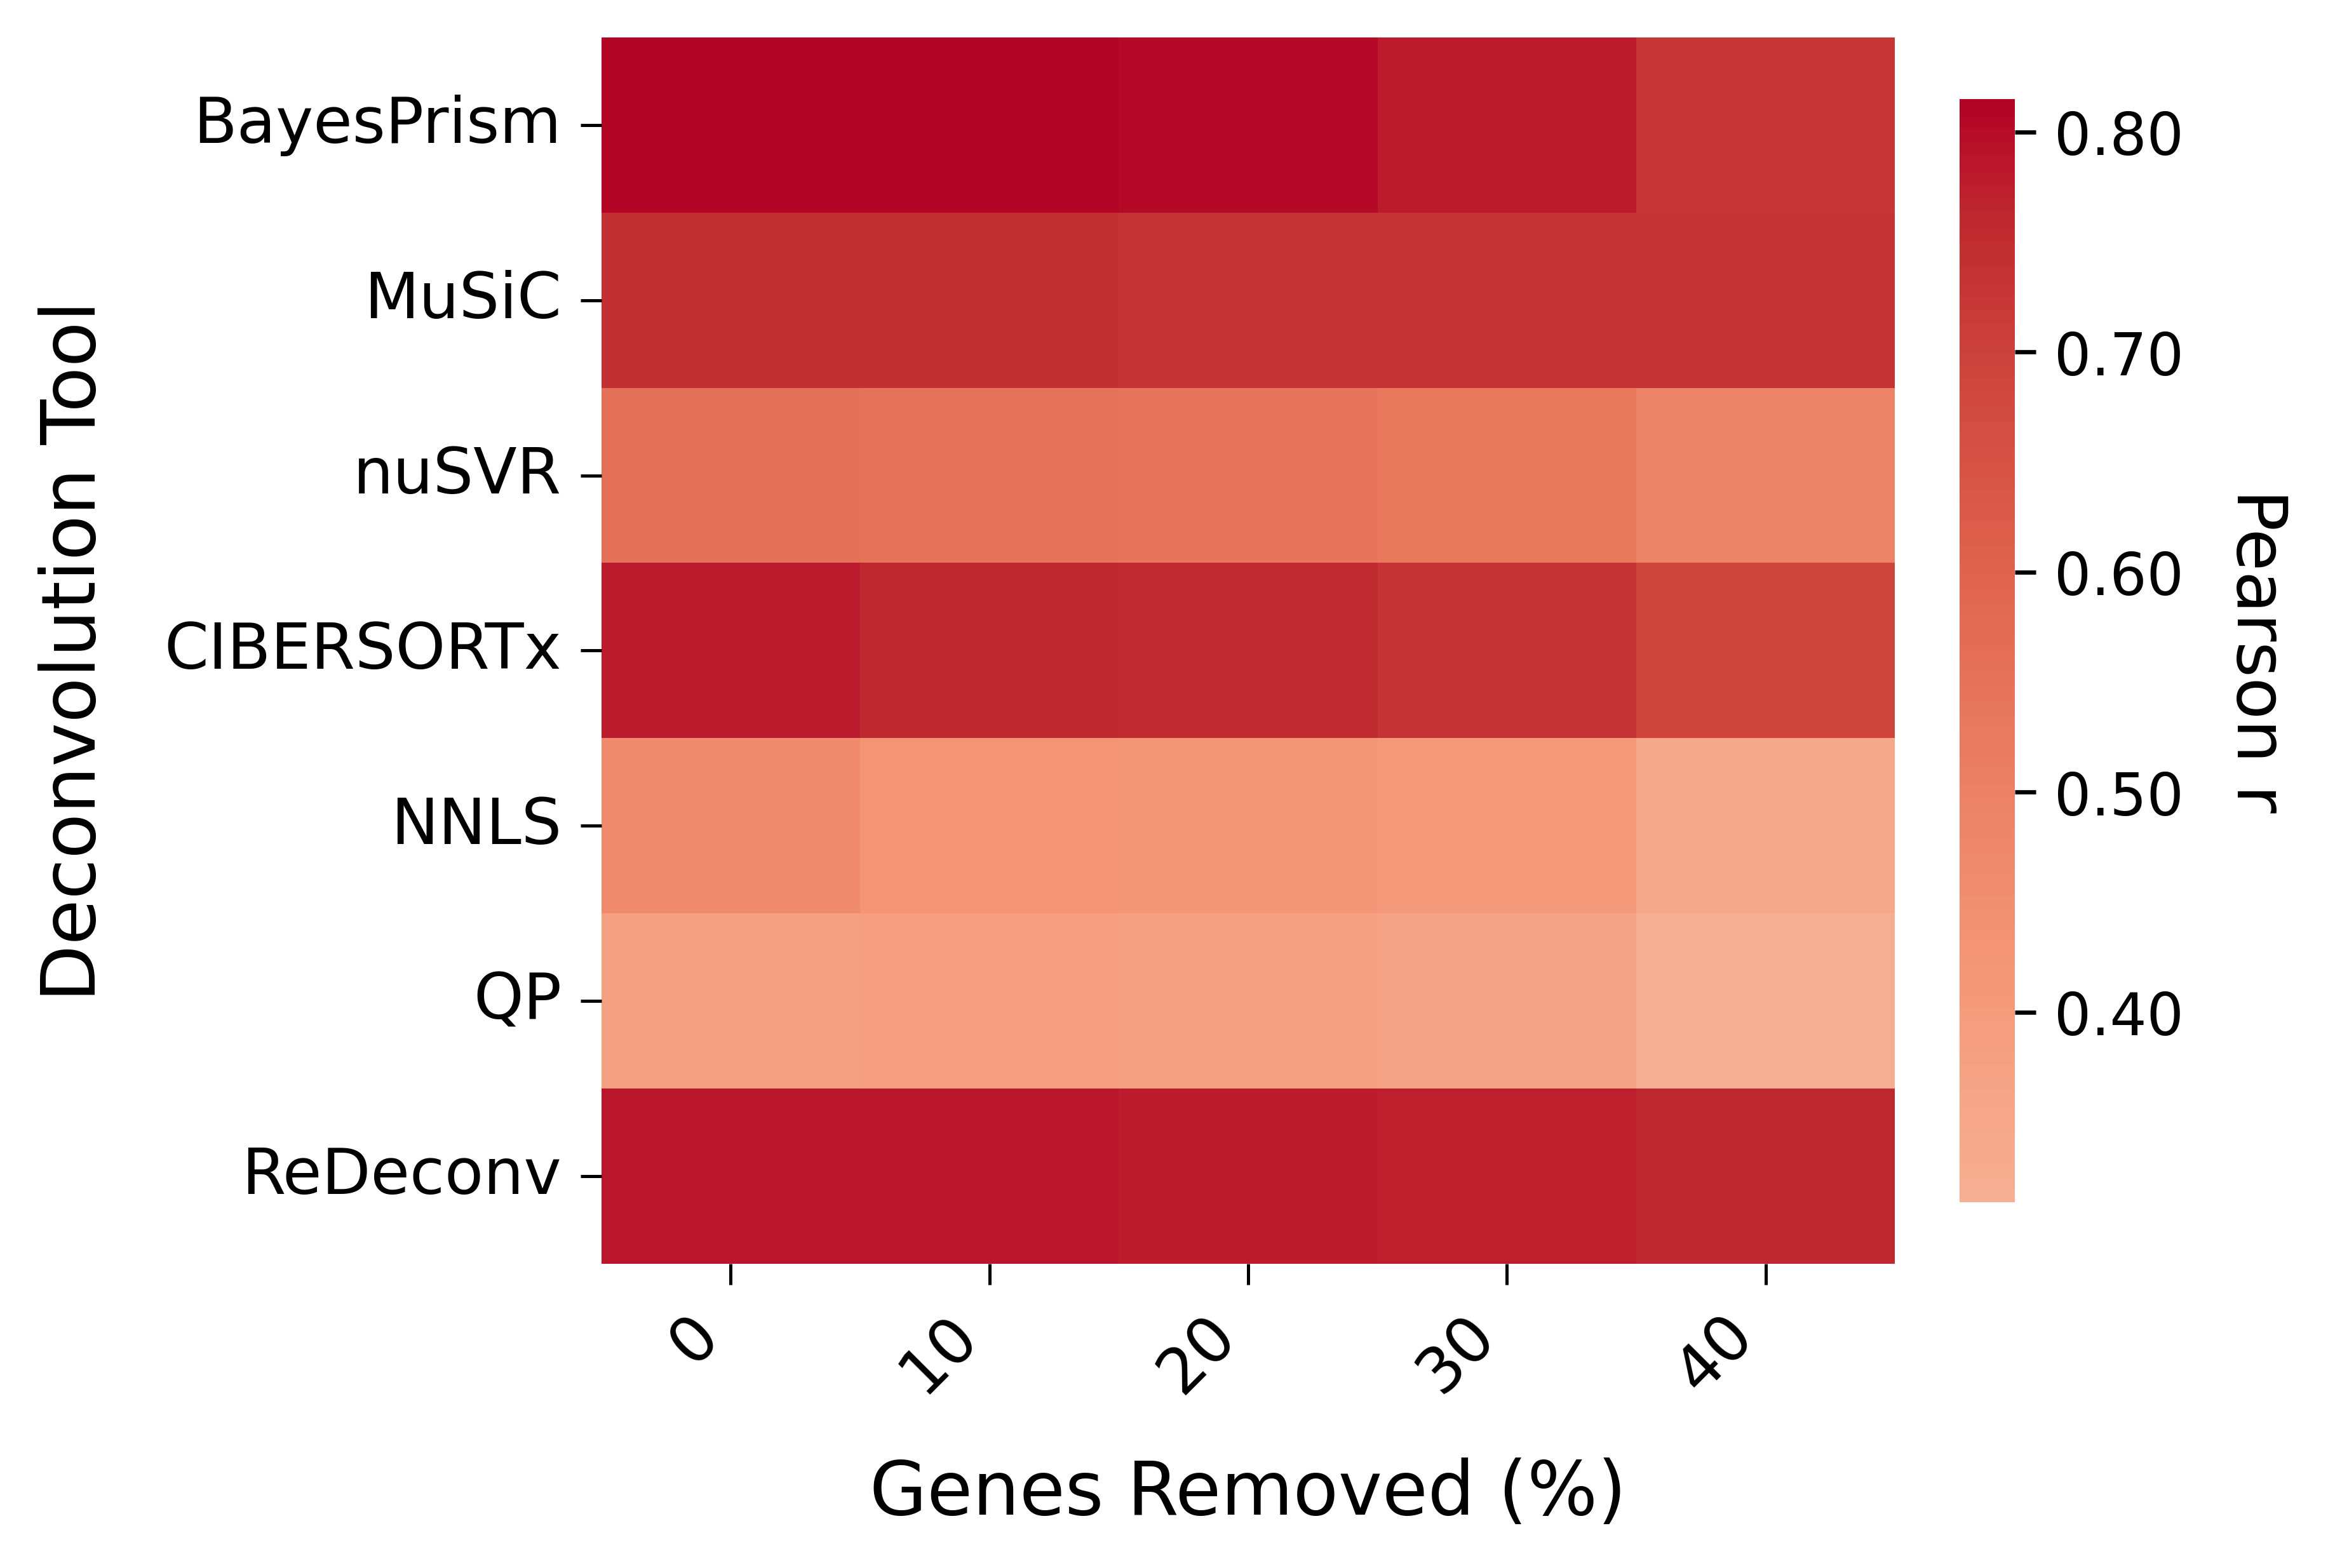

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# === LOAD DATA ===
file_path = 'All_Pearson_Summary.csv'
df = pd.read_csv(file_path, sep='\t')

# === ENSURE NUMERIC NOISE LEVEL FOR ORDERING ===
df['RemovedGenesNumeric'] = pd.to_numeric(df['RemovedGenes'], errors='coerce')

# === PIVOT TO METHOD × GENE REMOVAL ===
pivot_df = df.pivot_table(
    index='Method',
    columns='RemovedGenesNumeric',
    values='Pearson_r',   
    aggfunc='mean'
).sort_index(axis=1)

# === REORDER ROWS ===
method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
pivot_df = pivot_df.reindex(method_order)

# === PLOT HEATMAP ===
fig, ax = plt.subplots(figsize=(6, 4), dpi=600, constrained_layout=True)
ax = sns.heatmap(
    pivot_df,
    cmap='coolwarm',
#    annot=True,
#    fmt=".1f",
#    annot_kws={"size": 10},
    cbar_kws={'shrink': 0.9},
    linewidths=0,
    linecolor='white',
    center=0 
)

# Force ticks to show
ax.tick_params(
    axis='x', which='both', bottom=True, top=False, labelbottom=True,
    length=4, width=0.6
)
ax.tick_params(
    axis='y', which='both', left=True, right=False, labelleft=True,
    length=4, width=0.6
)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Pearson r", fontsize=13, rotation=270, labelpad=20)   
cbar.ax.tick_params(labelsize=11, width=0.8, length=4)             # not too small, not too big
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))

# === Axes styling ===
plt.ylabel('Deconvolution Tool', fontsize=14, labelpad=10)
plt.xlabel('Genes Removed (%)', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# === SAVE & SHOW ===
out_path = 'COO-Decon-Degradation/Pearson_Heatmap_Degradation.svg'
plt.show()
fig.savefig(out_path)
plt.close(fig)

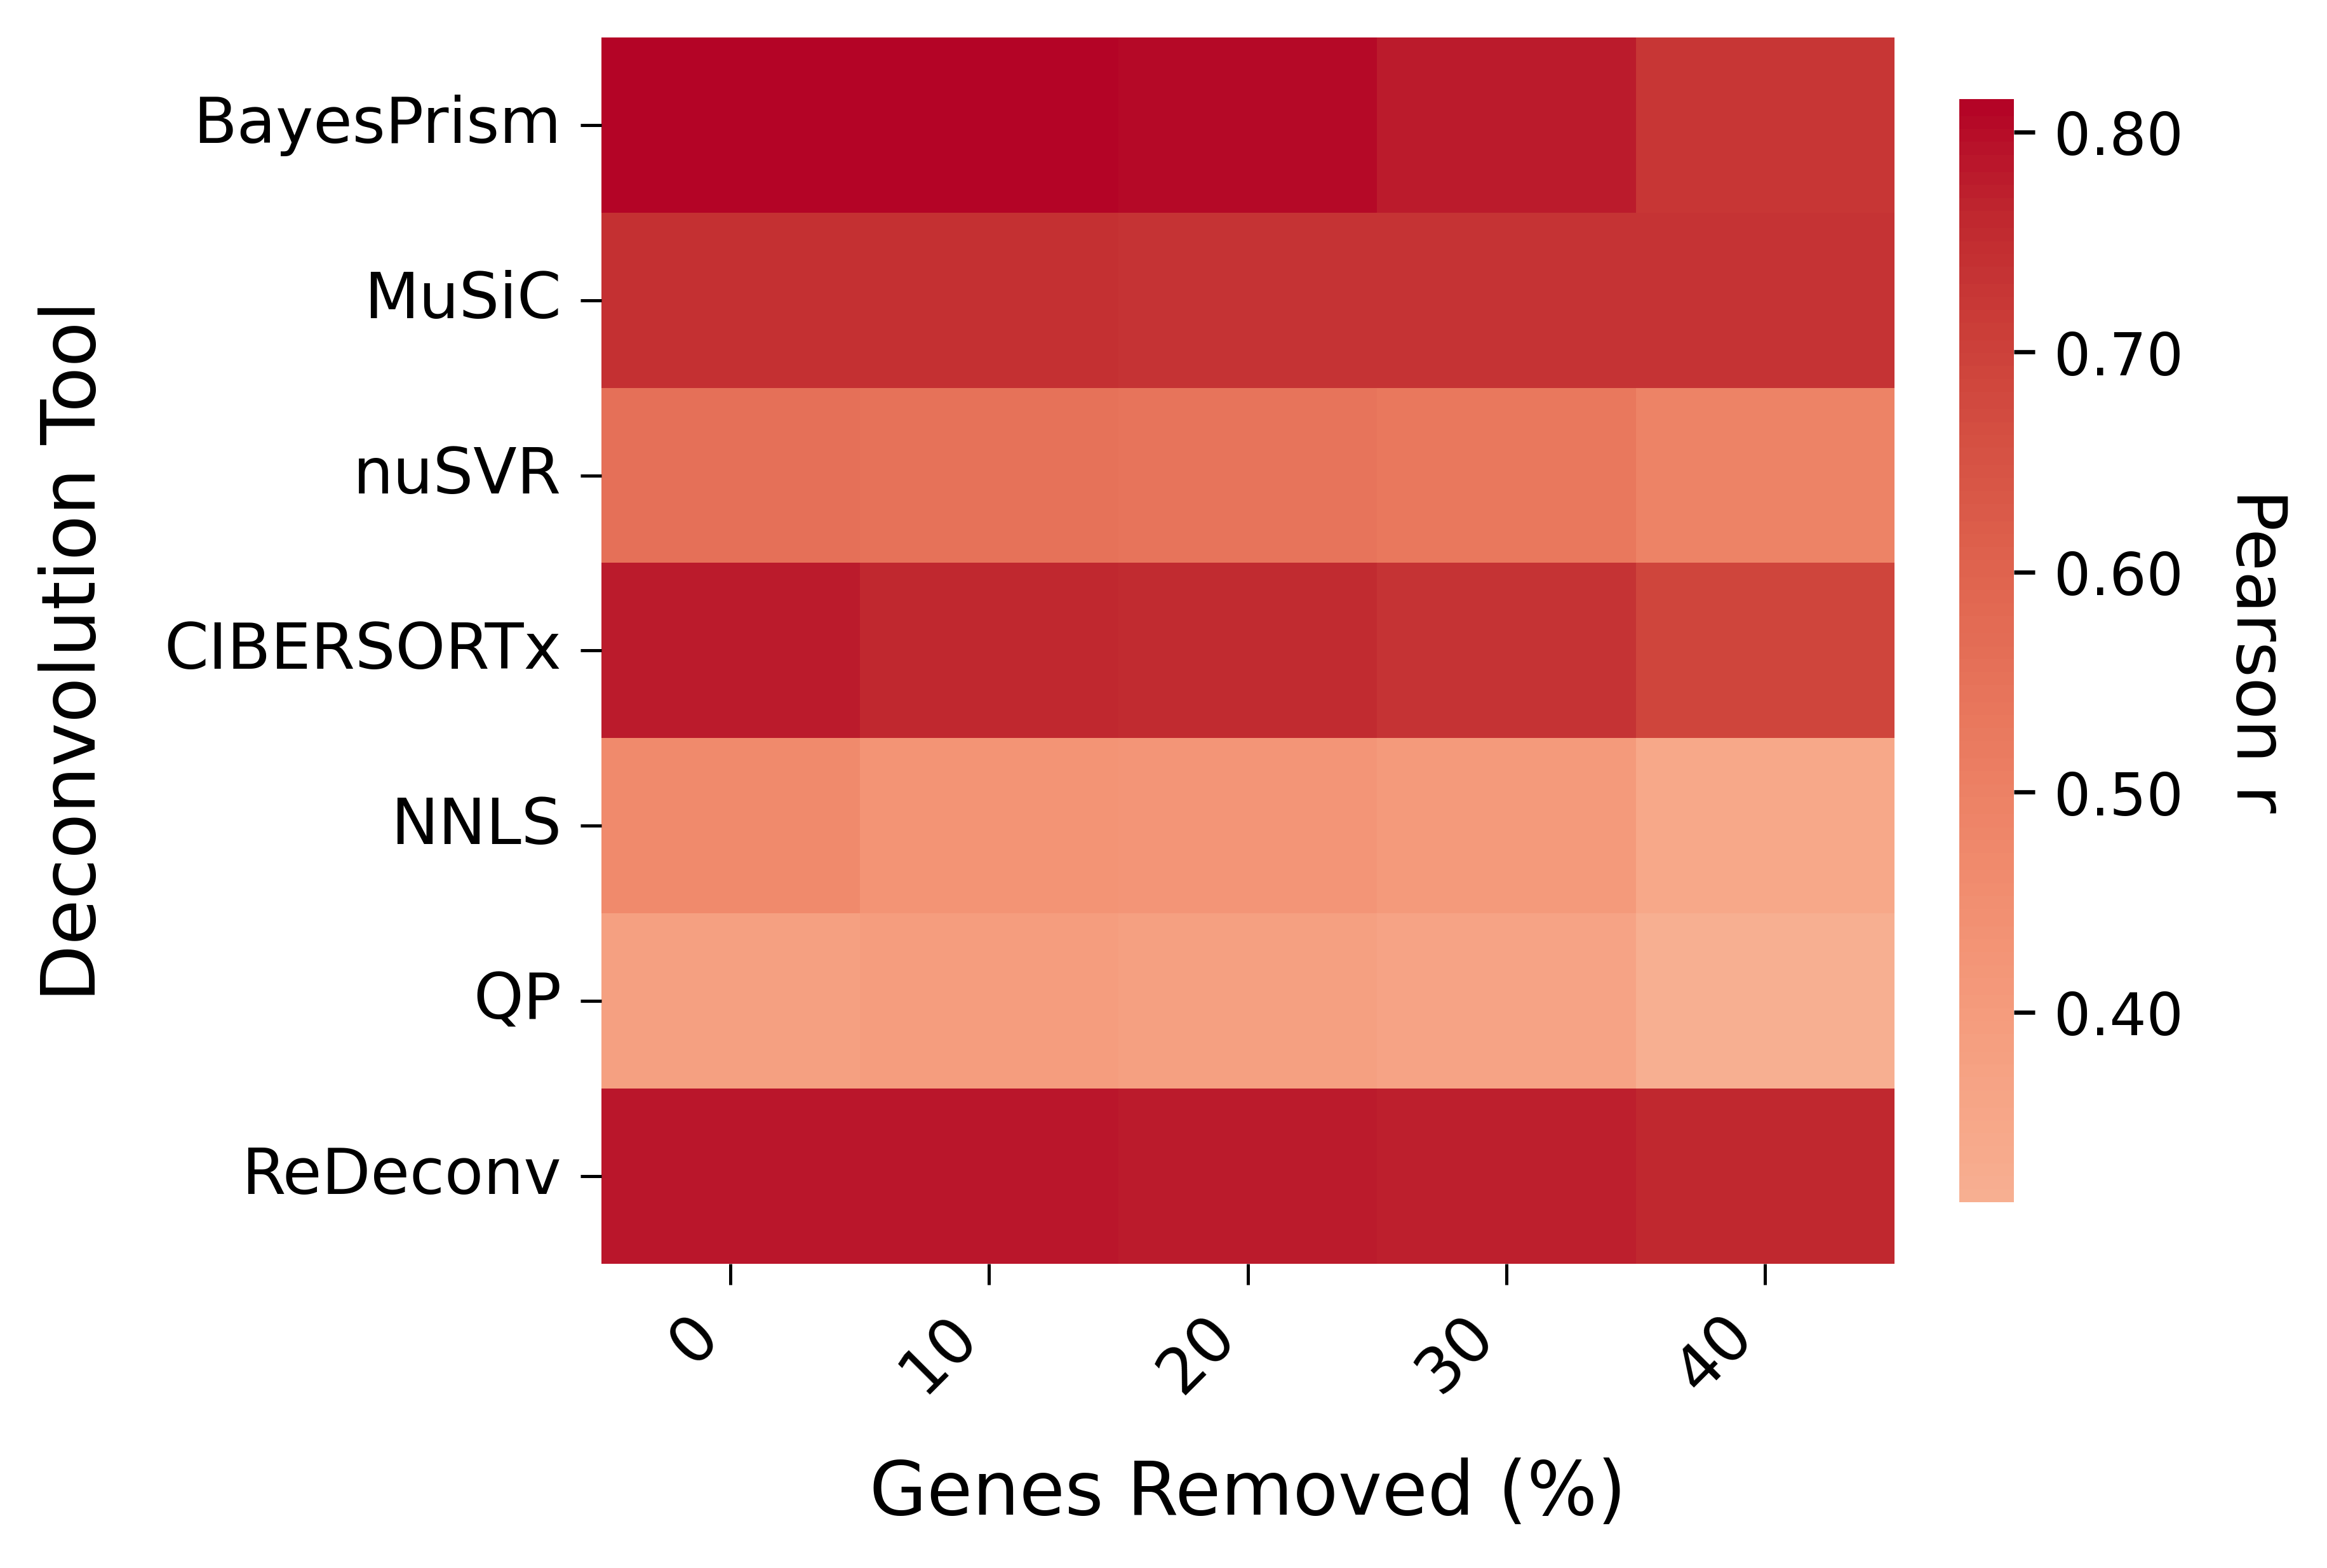

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# === LOAD DATA ===
file_path = 'All_Pearson_Summary.csv'
df = pd.read_csv(file_path, sep='\t')

# === ENSURE NUMERIC NOISE LEVEL FOR ORDERING ===
df['RemovedGenesNumeric'] = pd.to_numeric(df['RemovedGenes'], errors='coerce')

# === PIVOT TO METHOD × GENE REMOVAL ===
pivot_df = df.pivot_table(
    index='Method',
    columns='RemovedGenesNumeric',
    values='Pearson_r',   
    aggfunc='mean'
).sort_index(axis=1)

# === REORDER ROWS ===
method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
pivot_df = pivot_df.reindex(method_order)

# === PLOT HEATMAP ===
fig, ax = plt.subplots(figsize=(6, 4), dpi=600, constrained_layout=True)
ax = sns.heatmap(
    pivot_df,
    cmap='coolwarm',
#    annot=True,
#    fmt=".1f",
#    annot_kws={"size": 10},
    cbar_kws={'shrink': 0.9},
    linewidths=0,
    linecolor='white',
    center=0 
)

# Force ticks to show
ax.tick_params(
    axis='x', which='both', bottom=True, top=False, labelbottom=True,
    length=4, width=0.6
)
ax.tick_params(
    axis='y', which='both', left=True, right=False, labelleft=True,
    length=4, width=0.6
)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Pearson r", fontsize=13, rotation=270, labelpad=20)   
cbar.ax.tick_params(labelsize=11, width=0.8, length=4)             # not too small, not too big
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))

# === Axes styling ===
plt.ylabel('Deconvolution Tool', fontsize=14, labelpad=10)
plt.xlabel('Genes Removed (%)', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# === SAVE & SHOW ===
out_path = 'COO-Decon-Degradation/Pearson_Heatmap_Degradation_Clean.svg'
fig.savefig(out_path)
plt.show()
plt.close(fig)